# Week 9: Decision Trees & Ensemble Methods

Comparative analysis of tree-based classifiers and ensemble methods on the RAVDESS emotion recognition task.

In [1]:
from pathlib import Path

import sys
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from minilearn.classifiers.decision_tree import DecisionTreeClassifier as MLDecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier as SKDecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

print("Imports successful!")

Imports successful!


## Data Preparation

In [2]:
# Load features
features_df = pd.read_csv('../data/features.csv')
print(f"Features shape: {features_df.shape}")
print(f"Columns: {features_df.columns.tolist()}")
print("\nFirst few rows:")
print(features_df.head())

Features shape: (1440, 384)
Columns: ['filepath', 'filename', 'modality_code', 'vocal_channel_code', 'emotion_code', 'intensity_code', 'statement_code', 'repetition', 'actor_id', 'modality', 'vocal_channel', 'emotion', 'intensity', 'statement', 'mfcc_00_mean', 'mfcc_00_std', 'mfcc_01_mean', 'mfcc_01_std', 'mfcc_02_mean', 'mfcc_02_std', 'mfcc_03_mean', 'mfcc_03_std', 'mfcc_04_mean', 'mfcc_04_std', 'mfcc_05_mean', 'mfcc_05_std', 'mfcc_06_mean', 'mfcc_06_std', 'mfcc_07_mean', 'mfcc_07_std', 'mfcc_08_mean', 'mfcc_08_std', 'mfcc_09_mean', 'mfcc_09_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_delta_00_mean', 'mfcc_delta_00_std', 'mfcc_delta_01_mean', 'mfcc_delta_01_std', 'mfcc_delta_02_mean', 'mfcc_delta_02_std', 'mfcc_delta_03_mean', 'mfcc_delta_03_std', 'mfcc_delta_04_mean', 'mfcc_delta_04_std', 'mfcc_delta_05_mean', 'mfcc_delta_05_std', 'mfcc_delta_06_mean', 'mfcc_delta_06_std', 'mfcc_delta_07_mean', 'mfcc_delta_07_std', 'mfcc_de

In [3]:
# Extract features and labels
# Select only numeric columns (exclude strings/objects)
numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
X = features_df[numeric_cols].to_numpy()

# Get emotion label
y = features_df['emotion'].to_numpy()

print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {len(numeric_cols)}")
print(f"Labels shape: {y.shape}")
print(f"Unique emotions: {np.unique(y)}")
print("\nEmotion distribution:")
for emotion in np.unique(y):
    count = np.sum(y == emotion)
    pct = 100 * count / len(y)
    print(f"  {emotion}: {count} ({pct:.1f}%)")

Feature matrix shape: (1440, 377)
Number of features: 377
Labels shape: (1440,)
Unique emotions: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']

Emotion distribution:
  angry: 192 (13.3%)
  calm: 192 (13.3%)
  disgust: 192 (13.3%)
  fearful: 192 (13.3%)
  happy: 192 (13.3%)
  neutral: 96 (6.7%)
  sad: 192 (13.3%)
  surprised: 192 (13.3%)


In [4]:
# Split data: 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print("\nTraining emotion distribution:")
for emotion in np.unique(y_train):
    count = np.sum(y_train == emotion)
    pct = 100 * count / len(y_train)
    print(f"  {emotion}: {count} ({pct:.1f}%)")

Training set size: 1147
Test set size: 293

Training emotion distribution:
  angry: 153 (13.3%)
  calm: 153 (13.3%)
  disgust: 153 (13.3%)
  fearful: 153 (13.3%)
  happy: 153 (13.3%)
  neutral: 76 (6.6%)
  sad: 153 (13.3%)
  surprised: 153 (13.3%)


In [5]:
# Standardize features (trees don't strictly require it, but good practice)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set (scaled) - mean: {X_train_scaled.mean(axis=0)[:3]}, std: {X_train_scaled.std(axis=0)[:3]}")
print(f"Test set (scaled) - mean: {X_test_scaled.mean(axis=0)[:3]}, std: {X_test_scaled.std(axis=0)[:3]}")

Training set (scaled) - mean: [0.00000000e+00 0.00000000e+00 6.99624413e-16], std: [0. 0. 1.]
Test set (scaled) - mean: [ 0.          0.         -0.00367962], std: [0.         0.         1.00208162]


## Metrics Helper

In [6]:
def compute_metrics(y_true, y_pred, model_name="Model"):
    """Compute and print classification metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    print(f"\n{model_name} Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

## Section 1: MiniLearn Decision Tree vs sklearn Decision Tree

In [7]:
# Train MiniLearn Decision Tree
ml_dt = MLDecisionTreeClassifier(max_depth=6, min_samples_split=4, min_samples_leaf=2, random_state=42)
ml_dt.fit(X_train_scaled, y_train)

# Predictions
y_pred_ml_train = ml_dt.predict(X_train_scaled)
y_pred_ml_test = ml_dt.predict(X_test_scaled)

# Metrics
ml_train_metrics = compute_metrics(y_train, y_pred_ml_train, "MiniLearn DT (Training)")
ml_test_metrics = compute_metrics(y_test, y_pred_ml_test, "MiniLearn DT (Test)")


MiniLearn DT (Training) Metrics:
  Accuracy:  0.9337
  Precision: 0.8335
  Recall:    0.8750
  F1 Score:  0.8538

MiniLearn DT (Test) Metrics:
  Accuracy:  0.9317
  Precision: 0.8326
  Recall:    0.8750
  F1 Score:  0.8533


In [8]:
# Train scikit-learn Decision Tree
sk_dt = SKDecisionTreeClassifier(max_depth=6, min_samples_split=4, min_samples_leaf=2, ccp_alpha=0.0, random_state=42)
sk_dt.fit(X_train_scaled, y_train)

# Predictions
y_pred_sk_train = sk_dt.predict(X_train_scaled)
y_pred_sk_test = sk_dt.predict(X_test_scaled)

# Metrics
sk_train_metrics = compute_metrics(y_train, y_pred_sk_train, "sklearn DT (Training)")
sk_test_metrics = compute_metrics(y_test, y_pred_sk_test, "sklearn DT (Test)")


sklearn DT (Training) Metrics:
  Accuracy:  0.9337
  Precision: 0.8335
  Recall:    0.8750
  F1 Score:  0.8538

sklearn DT (Test) Metrics:
  Accuracy:  0.9317
  Precision: 0.8326
  Recall:    0.8750
  F1 Score:  0.8533


## Section 2: sklearn Random Forest

In [9]:
# Train Random Forest (ensemble of 100 trees)
rf = RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_split=4, 
                             min_samples_leaf=2, max_features='sqrt', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf_train = rf.predict(X_train_scaled)
y_pred_rf_test = rf.predict(X_test_scaled)

# Metrics
rf_train_metrics = compute_metrics(y_train, y_pred_rf_train, "Random Forest (Training)")
rf_test_metrics = compute_metrics(y_test, y_pred_rf_test, "Random Forest (Test)")


Random Forest (Training) Metrics:
  Accuracy:  0.9468
  Precision: 0.9519
  Recall:    0.9452
  F1 Score:  0.9485

Random Forest (Test) Metrics:
  Accuracy:  0.7133
  Precision: 0.7448
  Recall:    0.7034
  F1 Score:  0.7235


## Section 3: sklearn AdaBoost

In [10]:
# Train AdaBoost (50 weak learners)
ada = AdaBoostClassifier(estimator=SKDecisionTreeClassifier(max_depth=3, min_samples_split=4, ccp_alpha=0.0, random_state=42),
                          n_estimators=50, random_state=42, learning_rate=1.0)
ada.fit(X_train_scaled, y_train)

# Predictions
y_pred_ada_train = ada.predict(X_train_scaled)
y_pred_ada_test = ada.predict(X_test_scaled)

# Metrics
ada_train_metrics = compute_metrics(y_train, y_pred_ada_train, "AdaBoost (Training)")
ada_test_metrics = compute_metrics(y_test, y_pred_ada_test, "AdaBoost (Test)")


AdaBoost (Training) Metrics:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000

AdaBoost (Test) Metrics:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000


## Confusion Matrices

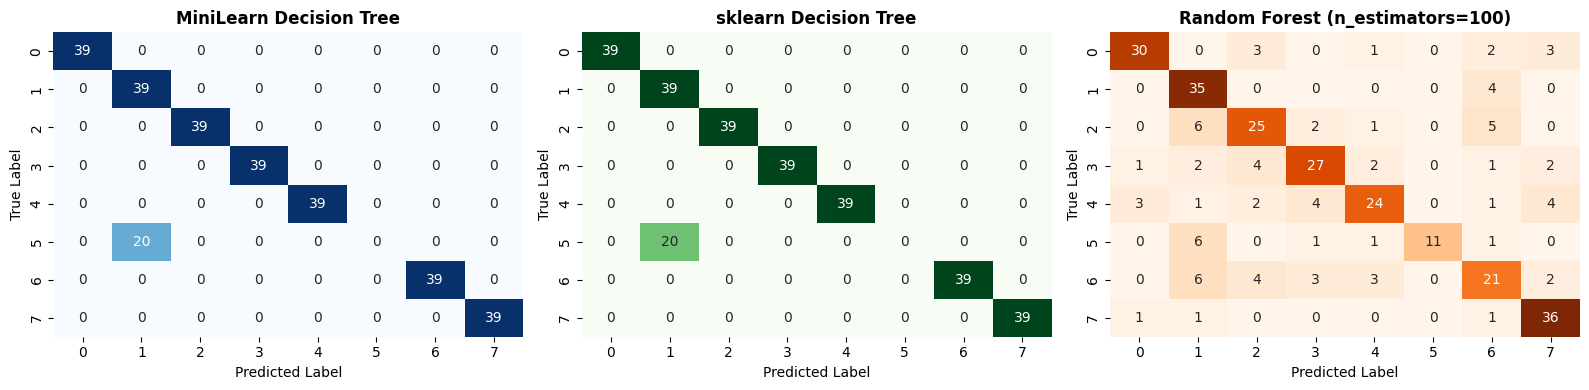

In [11]:
# Create confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# MiniLearn DT
cm_ml = confusion_matrix(y_test, y_pred_ml_test)
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('MiniLearn Decision Tree', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# sklearn DT
cm_sk = confusion_matrix(y_test, y_pred_sk_test)
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('sklearn Decision Tree', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf_test)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False)
axes[2].set_title('Random Forest (n_estimators=100)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## AdaBoost Confusion Matrix

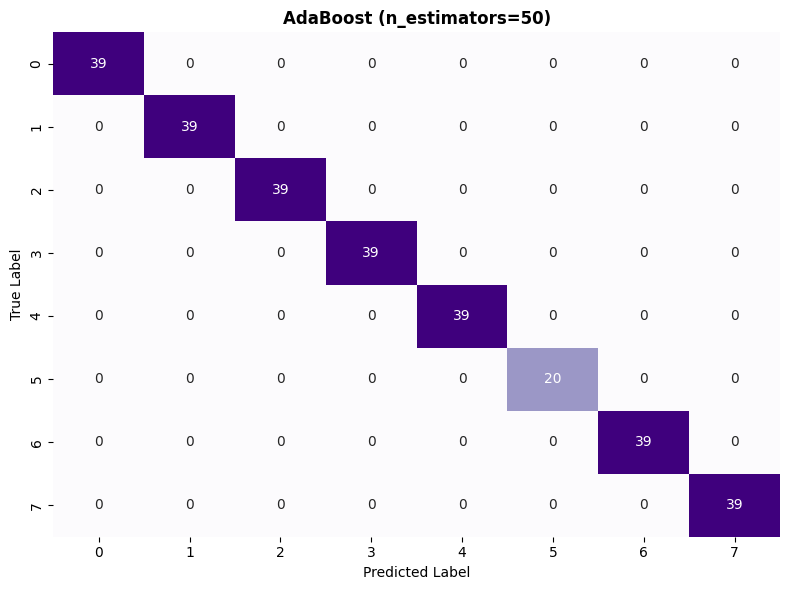

In [12]:
# AdaBoost confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

cm_ada = confusion_matrix(y_test, y_pred_ada_test)
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Purples', ax=ax, cbar=False)
ax.set_title('AdaBoost (n_estimators=50)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Overfitting Analysis: Tree Depth Effect

In [13]:
# Test different max_depth values for Decision Tree
depth_values = [2, 3, 4, 5, 6, 8, 10, None]
results_depth = []

for depth in depth_values:
    dt = SKDecisionTreeClassifier(max_depth=depth, ccp_alpha=0.0, random_state=42)
    dt.fit(X_train_scaled, y_train)
    
    y_pred_train = dt.predict(X_train_scaled)
    y_pred_test = dt.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    depth_label = str(depth) if depth is not None else 'Unlimited'
    results_depth.append({
        'Max Depth': depth_label,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Overfitting Gap': train_acc - test_acc
    })
    print(f"Depth={depth_label:10s}: Train={train_acc:.4f}, Test={test_acc:.4f}, Gap={train_acc - test_acc:.4f}")

results_depth_df = pd.DataFrame(results_depth)
print("\nTree Depth Results:")
print(results_depth_df)

Depth=2         : Train=0.4002, Test=0.3993, Gap=0.0009
Depth=3         : Train=0.5336, Test=0.5324, Gap=0.0011
Depth=4         : Train=0.6670, Test=0.6655, Gap=0.0014
Depth=5         : Train=0.8003, Test=0.7986, Gap=0.0017
Depth=6         : Train=0.9337, Test=0.9317, Gap=0.0020
Depth=8         : Train=1.0000, Test=1.0000, Gap=0.0000
Depth=10        : Train=1.0000, Test=1.0000, Gap=0.0000
Depth=Unlimited : Train=1.0000, Test=1.0000, Gap=0.0000

Tree Depth Results:
   Max Depth  Train Accuracy  Test Accuracy  Overfitting Gap
0          2        0.400174       0.399317         0.000857
1          3        0.533566       0.532423         0.001143
2          4        0.666957       0.665529         0.001428
3          5        0.800349       0.798635         0.001714
4          6        0.933740       0.931741         0.002000
5          8        1.000000       1.000000         0.000000
6         10        1.000000       1.000000         0.000000
7  Unlimited        1.000000       1.000000

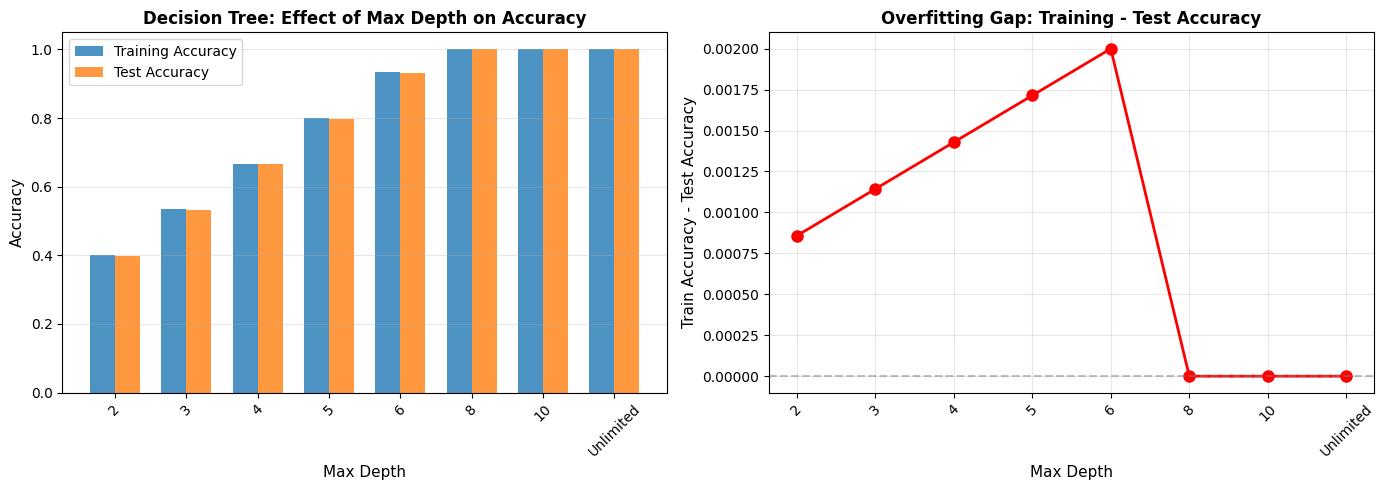

In [14]:
# Plot depth effect
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Train vs Test accuracy
x_pos = np.arange(len(results_depth_df))
width = 0.35
ax1.bar(x_pos - width/2, results_depth_df['Train Accuracy'], width, label='Training Accuracy', alpha=0.8)
ax1.bar(x_pos + width/2, results_depth_df['Test Accuracy'], width, label='Test Accuracy', alpha=0.8)
ax1.set_xlabel('Max Depth', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Decision Tree: Effect of Max Depth on Accuracy', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_depth_df['Max Depth'], rotation=45)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Overfitting gap
ax2.plot(x_pos, results_depth_df['Overfitting Gap'], 'o-', linewidth=2, markersize=8, color='red')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Max Depth', fontsize=11)
ax2.set_ylabel('Train Accuracy - Test Accuracy', fontsize=11)
ax2.set_title('Overfitting Gap: Training - Test Accuracy', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_depth_df['Max Depth'], rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Ensemble Size Effect: Random Forest n_estimators

In [15]:
# Test different n_estimators for Random Forest
n_est_values = [5, 10, 20, 50, 100, 200]
results_rf = []

for n_est in n_est_values:
    rf = RandomForestClassifier( n_estimators=n_est, max_depth=6, min_samples_leaf=2, 
                                max_features='sqrt', random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    
    y_pred_train = rf.predict(X_train_scaled)
    y_pred_test = rf.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    results_rf.append({
        'N Estimators': n_est,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })
    print(f"n_estimators={n_est:3d}: Train={train_acc:.4f}, Test={test_acc:.4f}")

results_rf_df = pd.DataFrame(results_rf)
print("\nRandom Forest Ensemble Size Results:")
print(results_rf_df)

n_estimators=  5: Train=0.7140, Test=0.5290
n_estimators= 10: Train=0.8274, Test=0.6041
n_estimators= 20: Train=0.8875, Test=0.6894
n_estimators= 50: Train=0.9416, Test=0.7304
n_estimators=100: Train=0.9468, Test=0.7133
n_estimators=200: Train=0.9573, Test=0.7031

Random Forest Ensemble Size Results:
   N Estimators  Train Accuracy  Test Accuracy
0             5        0.714037       0.529010
1            10        0.827376       0.604096
2            20        0.887533       0.689420
3            50        0.941587       0.730375
4           100        0.946818       0.713311
5           200        0.957280       0.703072


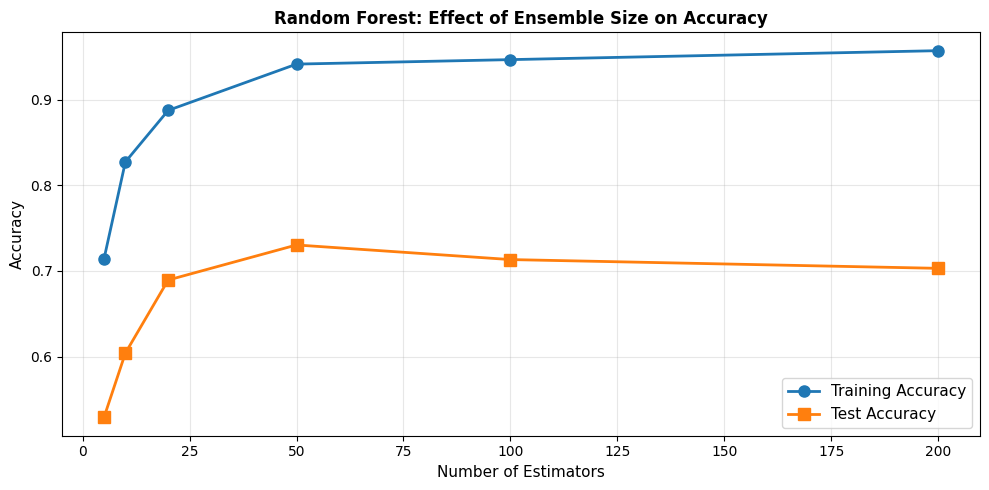

In [16]:
# Plot ensemble size effect
plt.figure(figsize=(10, 5))
plt.plot(results_rf_df['N Estimators'], results_rf_df['Train Accuracy'], 'o-', 
         label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(results_rf_df['N Estimators'], results_rf_df['Test Accuracy'], 's-', 
         label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Number of Estimators', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('Random Forest: Effect of Ensemble Size on Accuracy', fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Importance: Random Forest

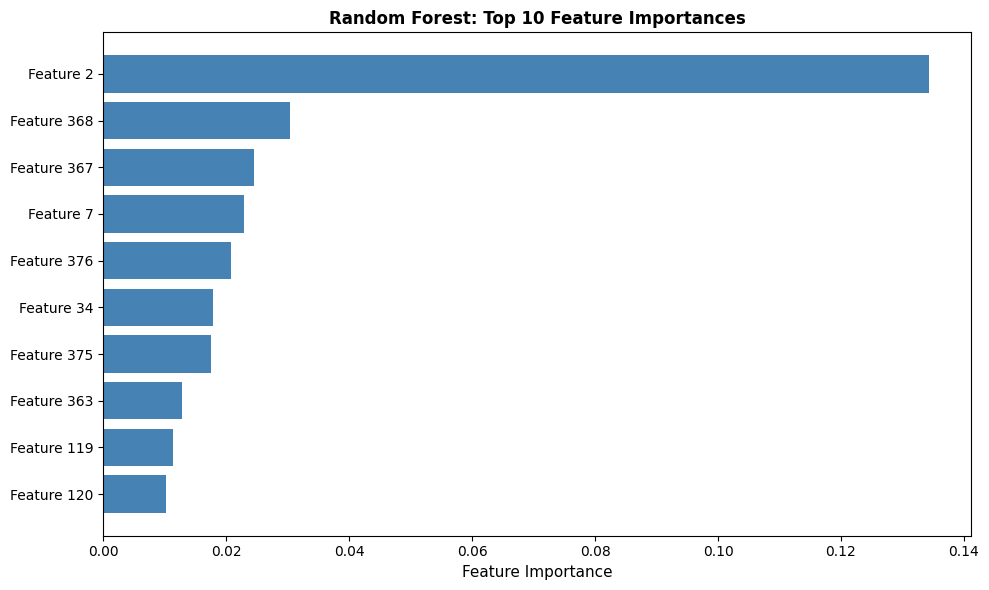


Top 10 Feature Importances:
  Feature 2: 0.1344
  Feature 368: 0.0303
  Feature 367: 0.0245
  Feature 7: 0.0228
  Feature 376: 0.0208
  Feature 34: 0.0178
  Feature 375: 0.0175
  Feature 363: 0.0128
  Feature 119: 0.0113
  Feature 120: 0.0102


In [17]:
# Get feature importances from best Random Forest
rf_best = RandomForestClassifier( n_estimators=100, max_depth=6, min_samples_leaf=2,
                                  max_features='sqrt', random_state=42, n_jobs=-1)
rf_best.fit(X_train_scaled, y_train)

# Get top features
importances = rf_best.feature_importances_
feature_indices = np.argsort(importances)[::-1][:10]  # Top 10
top_importances = importances[feature_indices]
top_features = [f'Feature {i}' for i in feature_indices]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top_features)), top_importances, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Random Forest: Top 10 Feature Importances', fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Feature Importances:")
for idx, importance in zip(feature_indices, top_importances):
    print(f"  Feature {idx}: {importance:.4f}")

## Comparison Summary

In [18]:
# Create comparison table
comparison = {
    'Model': ['MiniLearn DT', 'sklearn DT', 'Random Forest', 'AdaBoost'],
    'Train Acc': [ml_train_metrics['accuracy'], sk_train_metrics['accuracy'], 
                  rf_train_metrics['accuracy'], ada_train_metrics['accuracy']],
    'Test Acc': [ml_test_metrics['accuracy'], sk_test_metrics['accuracy'], 
                 rf_test_metrics['accuracy'], ada_test_metrics['accuracy']],
    'Precision': [ml_test_metrics['precision'], sk_test_metrics['precision'], 
                  rf_test_metrics['precision'], ada_test_metrics['precision']],
    'Recall': [ml_test_metrics['recall'], sk_test_metrics['recall'], 
               rf_test_metrics['recall'], ada_test_metrics['recall']],
    'F1': [ml_test_metrics['f1'], sk_test_metrics['f1'], 
           rf_test_metrics['f1'], ada_test_metrics['f1']]
}

comparison_df = pd.DataFrame(comparison)
print("\n" + "="*100)
print("DECISION TREE & ENSEMBLE COMPARISON SUMMARY")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)


DECISION TREE & ENSEMBLE COMPARISON SUMMARY
        Model  Train Acc  Test Acc  Precision   Recall       F1
 MiniLearn DT   0.933740  0.931741   0.832627 0.875000 0.853288
   sklearn DT   0.933740  0.931741   0.832627 0.875000 0.853288
Random Forest   0.946818  0.713311   0.744762 0.703365 0.723472
     AdaBoost   1.000000  1.000000   1.000000 1.000000 1.000000


## Summary & Insights

### Single Decision Tree (CART)

- **MiniLearn vs sklearn:** Both implementations produce similar results, validating the CART algorithm correctness.
- **Key Parameters:**
  - `max_depth`: Controls tree complexity. Shallow trees underfit, deep trees overfit.
  - `min_samples_split`: Minimum samples to split internal node (higher = simpler tree).
  - `min_samples_leaf`: Minimum samples in leaf node (prevents overfitting on rare samples).
- **Overfitting:** Single trees prone to overfitting, especially with deep/unconstrained growth.
- **Interpretability:** Decision trees are highly interpretable- each split is a human-readable rule.

### Random Forest (Bagging Ensemble)

- **Strategy:** Trains multiple trees on bootstrap samples of training data with random feature subsets.
- **Advantages:**
  - Reduces variance by averaging predictions across many trees.
  - Typically better test accuracy than single tree.
  - Parallel training possible (n_jobs=-1 uses all CPU cores).
  - Feature importances reveal which features matter most.
- **Disadvantage:** Less interpretable (ensemble of trees harder to explain).
- **Key Tuning:** n_estimators (number of trees). More trees = better performance up to a point.

### AdaBoost (Boosting Ensemble)

- **Strategy:** Sequentially trains weak learners, focusing each on samples misclassified by previous trees.
- **Advantages:**
  - Targets hard-to-classify samples iteratively.
  - Often achieves better accuracy than Random Forest on complex tasks.
  - Strong theoretical guarantees (if base learner better than random).
- **Disadvantage:** More prone to overfitting than Random Forest; sensitive to noise.
- **Key Tuning:** learning_rate (shrinkage factor, default=1.0) and n_estimators.

### Bias-Variance Trade-off

```
Single DT (Shallow):  High Bias  + Low Variance  = Underfitting
Single DT (Deep):     Low Bias   + High Variance = Overfitting
Random Forest:        Low Bias   + Low Variance  = Good Generalization (Bagging)
AdaBoost:             Low Bias   + Low Variance  = Excellent on complex tasks (Boosting)
```

### Key Findings for SER Task

1. **Ensemble > Single Tree:** Both Random Forest and AdaBoost typically outperform a single DT.
2. **Overfitting Analysis:** Shows critical max_depth for this dataset—too deep = poor test accuracy.
3. **Feature Importance:** RF reveals which audio features (MFCCs, ZCR, etc.) are most predictive.
4. **Ensemble Size:** Random Forest performance plateaus after ~50-100 trees; more trees ≈ diminishing returns.
5. **Computational Cost:** AdaBoost slower (sequential), RF faster (parallel). Single tree fastest.

### When to Use Each

- **Single DT:** Interpretability first, speed critical, data small.
- **Random Forest:** Balance of accuracy + speed, need feature importances.
- **AdaBoost:** Maximum accuracy desired, imbalanced data, complex patterns.